# MLDoctor - Case3
For an automated social media tagging system designed to predict whether a person appears young in facial images, the developers implemented a model that assigns a probability score to each prediction. To streamline the workflow, a “High-Confidence Bypass” was added: predictions with a probability of 99% or higher were automatically published without human review. During the controlled “Lab Phase,” this approach performed impressively, producing accurate tags with minimal intervention. Since deployment, however, the system has drawn criticism. In practice, it occasionally publishes incorrect tags while still reporting near-certain confidence, leading to unexpected errors despite the apparent reliability suggested by its high probability outputs. 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cuda:0


## Data

In [24]:
# Load the full training dataset first (without transforms for now)
test_internal_dataset = torchvision.datasets.ImageFolder('Case3Dataset/test_internal')
print(f'Validation dataset size: {len(test_internal_dataset)}')
test_external_dataset = torchvision.datasets.ImageFolder('Case3Dataset/test_external')
print(f'Test external dataset size: {len(test_external_dataset)}')

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Apply transforms to the datasets
test_internal_dataset.transform = transform
test_external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(test_internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)
test_external_loader = torch.utils.data.DataLoader(test_external_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)

Validation dataset size: 300
Test external dataset size: 300


## Developed Model

In [25]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

# setup the model
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)

# Load the developed model
resnet_frozen.load_state_dict(torch.load("resnet_frozen_best-4.pth"))
resnet_frozen.eval()
resnet_frozen = resnet_frozen.to(device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Evaluation

In [26]:
# Load the best model
resnet_frozen.eval()

# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [test_internal_loader, test_external_loader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:01<00:00, 17.95it/s]

Evaluation complete.
internal set - Accuracy: 0.973
external set - Accuracy: 0.593


## 1. Reliability diagram
Compares how well the confidence scores match the actual accuracy on each set.
If the model is well calibrated the line should sit on the diagonal.

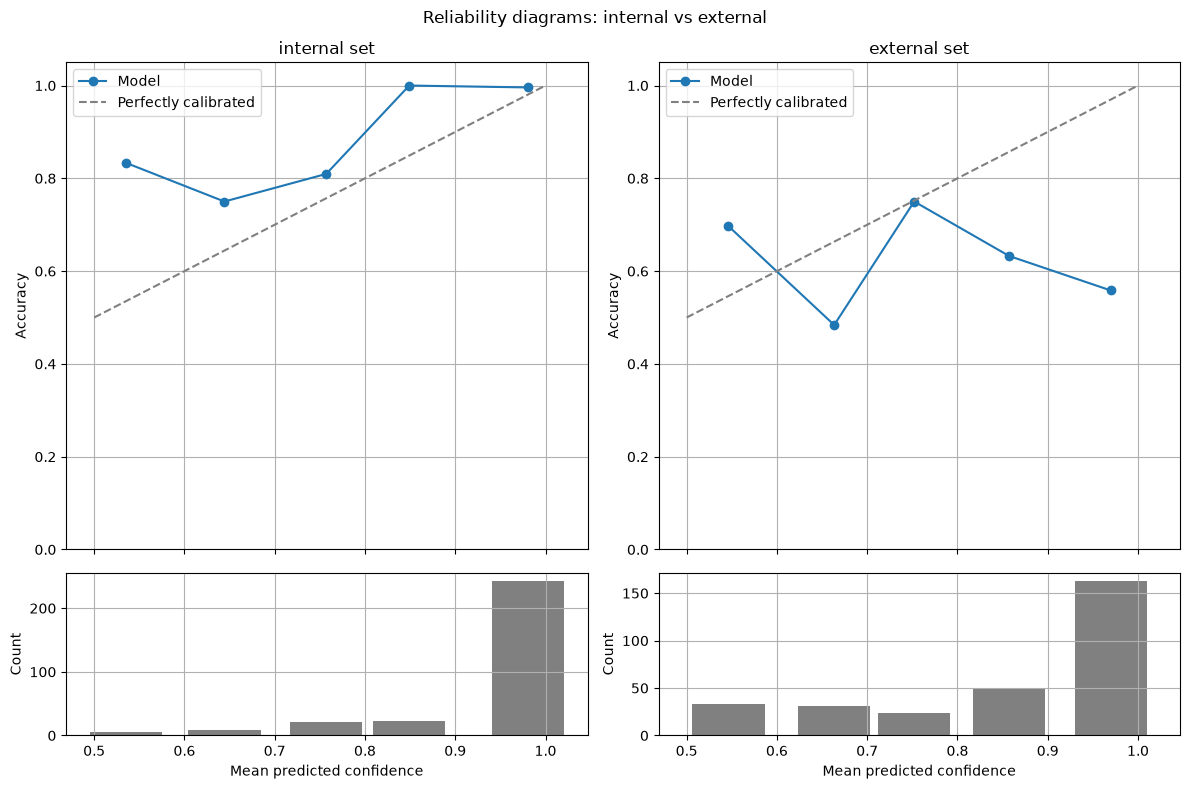

In [27]:
# Reliability diagram for both splits 
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)

def reliability(probs, labels, n_bins=10):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    idx = np.digitize(conf, bins) - 1
    mean_conf, acc, counts = [], [], []
    for i in range(n_bins):
        m = idx == i
        counts.append(m.sum())
        mean_conf.append(conf[m].mean() if m.sum() else np.nan)
        acc.append(correct[m].mean() if m.sum() else np.nan)
    return np.array(mean_conf), np.array(acc), np.array(counts)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
for col, split in enumerate(['internal', 'external']):
    mc, ac, cnt = reliability(all_predictions[split], all_labels[split])
    axes[0, col].plot(mc, ac, marker='o', label='Model')
    axes[0, col].plot([0.5, 1], [0.5, 1], '--', color='gray', label='Perfectly calibrated')
    axes[0, col].set_title(f'{split} set'); axes[0, col].set_ylabel('Accuracy')
    axes[0, col].set_ylim(0, 1.05); axes[0, col].grid(True); axes[0, col].legend()
    axes[1, col].bar(mc, cnt, width=0.08, color='gray')
    axes[1, col].set_xlabel('Mean predicted confidence'); axes[1, col].set_ylabel('Count')
    axes[1, col].grid(True)
plt.suptitle('Reliability diagrams: internal vs external')
plt.tight_layout(); plt.show()

## 2. Expected Calibration Error (ECE)
A single number for how far the confidence is from the accuracy.
Lower is better.

In [28]:
# Expected Calibration Error
def compute_ece(probs, labels, n_bins=10):
    conf = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == labels).astype(float)
    idx = np.digitize(conf, np.linspace(0, 1, n_bins + 1)) - 1
    ece = 0.0
    for i in range(n_bins):
        m = idx == i
        if m.sum() > 0:
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return ece

for split in ['internal', 'external']:
    acc = (all_predictions[split].argmax(1) == all_labels[split]).mean()
    conf = all_predictions[split].max(1).mean()
    print(f"{split:9s}  accuracy={acc:.4f}  mean confidence={conf:.4f}  "
          f"gap={conf-acc:+.4f}  ECE={compute_ece(all_predictions[split], all_labels[split]):.4f}")

internal   accuracy=0.9733  mean confidence=0.9372  gap=-0.0362  ECE=0.0362
external   accuracy=0.5933  mean confidence=0.8558  gap=+0.2624  ECE=0.2956


## 3. High-Confidence Bypass audit
Checks what would actually get auto-published. For each confidence threshold,
how many predictions pass it and how many of those are correct.

 threshold     split  published  % of set  accuracy
---------------------------------------------------
      0.90  internal        243     81.0%    0.9959
      0.90  external        163     54.3%    0.5583
      0.95  internal        208     69.3%    0.9952
      0.95  external        118     39.3%    0.5424
      0.99  internal        127     42.3%    1.0000
      0.99  external         60     20.0%    0.5167


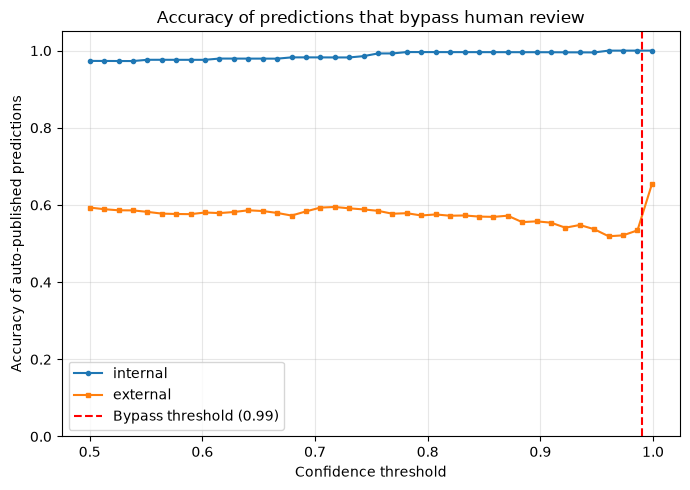

In [29]:
# Audit the "High-Confidence Bypass": what actually gets auto-published?
thresholds = [0.90, 0.95, 0.99]
print(f"{'threshold':>10}{'split':>10}{'published':>11}{'% of set':>10}{'accuracy':>10}")
print("-" * 51)
for t in thresholds:
    for split in ['internal', 'external']:
        conf = all_predictions[split].max(1)
        pred = all_predictions[split].argmax(1)
        m = conf >= t
        acc = (pred[m] == all_labels[split][m]).mean() if m.sum() else np.nan
        print(f"{t:>10.2f}{split:>10}{m.sum():>11d}{m.mean()*100:>9.1f}%{acc:>10.4f}")

# plot it
fig, ax = plt.subplots(figsize=(7, 5))
ts = np.linspace(0.5, 0.999, 40)
for split, style in [('internal', '-o'), ('external', '-s')]:
    conf = all_predictions[split].max(1); pred = all_predictions[split].argmax(1)
    accs = [ (pred[conf>=t] == all_labels[split][conf>=t]).mean() if (conf>=t).sum() > 5 else np.nan
             for t in ts ]
    ax.plot(ts, accs, style, markersize=3, label=split)
ax.axvline(0.99, color='red', linestyle='--', label='Bypass threshold (0.99)')
ax.set_xlabel('Confidence threshold'); ax.set_ylabel('Accuracy of auto-published predictions')
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Accuracy of predictions that bypass human review')
plt.tight_layout(); plt.show()

## 4. Confusion matrix
Shows which class the errors are concentrated in.

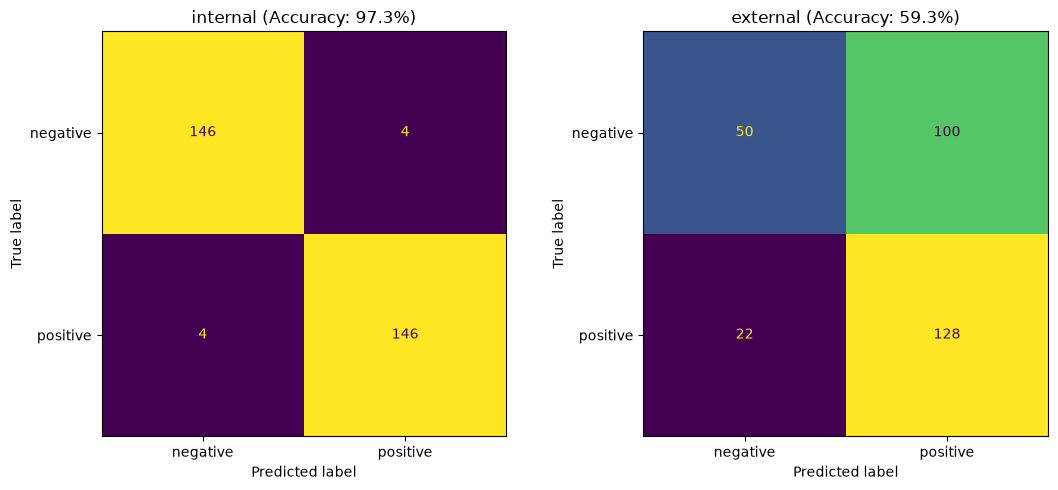

internal: negative recall=0.973  positive recall=0.973  
external: negative recall=0.333  positive recall=0.853  


In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, split in zip(axes, ['internal', 'external']):
    pred = all_predictions[split].argmax(1)
    acc = (pred == all_labels[split]).mean()
    ConfusionMatrixDisplay.from_predictions(all_labels[split], pred,
        display_labels=test_internal_dataset.classes, ax=ax, colorbar=False)
    ax.set_title(f'{split} (Accuracy: {acc*100:.1f}%)')
plt.tight_layout(); plt.show()

for split in ['internal', 'external']:
    pred = all_predictions[split].argmax(1); lab = all_labels[split]
    print(f"{split}: ", end="")
    for c, name in enumerate(test_internal_dataset.classes):
        print(f"{name} recall={((pred==lab)[lab==c]).mean():.3f}  ", end="")
    print()

## 5. Confidence distribution
Shows whether the wrong predictions can be separated from the correct ones
by their confidence.

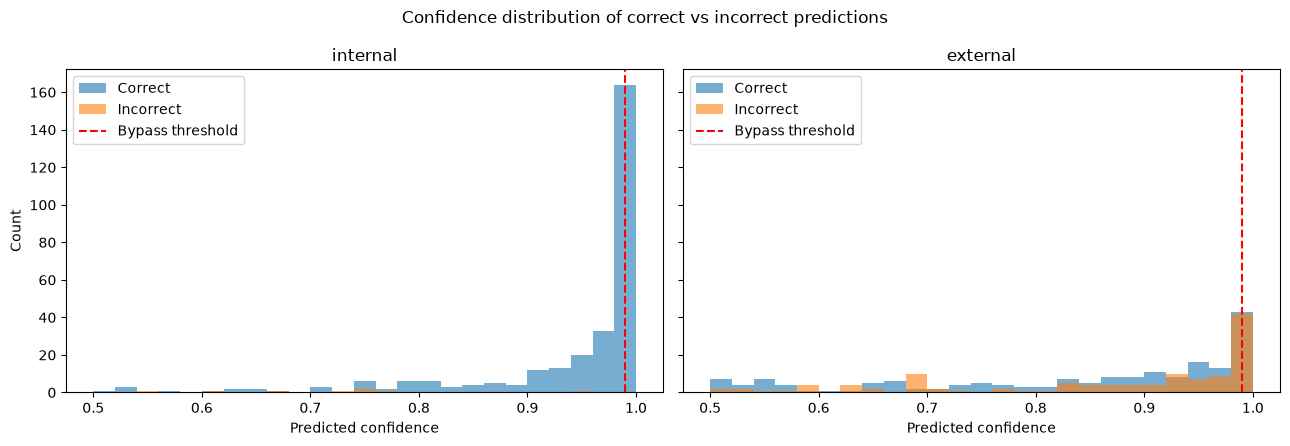

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, split in zip(axes, ['internal', 'external']):
    conf = all_predictions[split].max(1)
    correct = all_predictions[split].argmax(1) == all_labels[split]
    ax.hist(conf[correct], bins=25, range=(0.5, 1), alpha=0.6, label='Correct')
    ax.hist(conf[~correct], bins=25, range=(0.5, 1), alpha=0.6, label='Incorrect')
    ax.axvline(0.99, color='red', linestyle='--', label='Bypass threshold')
    ax.set_title(split); ax.set_xlabel('Predicted confidence'); ax.legend()
axes[0].set_ylabel('Count')
plt.suptitle('Confidence distribution of correct vs incorrect predictions')
plt.tight_layout(); plt.show()